In [1]:
import hoda
import tensorly as tl

print(tl.get_backend())
%pip freeze | grep moabb

cupy
moabb==0.4.6
Note: you may need to restart the kernel to use updated packages.


In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from moabb.evaluations import WithinSessionEvaluation

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
datasets = [
       #BI2012(),
       #BI2013a(),
       #BI2014a(),
       #BI2014b(),
       #BI2015a(),
       #BI2015b(),
       BNCI2014008(),
       BNCI2014009(),
       #BNCI2015_003(),
       #Cattan2019_VR(),
       #EPFLP300(),
       #Huebner2017(),
       #Huebner2018(),
       #Lee2019_ERP(),
       #Sosulski2019()   
   ]

evaluation = WithinSessionEvaluation(
    paradigm=paradigm,
    datasets=datasets,
    suffix="hoda",
    overwrite=False,
    random_state=42,
    n_jobs=4,
    #data_size=dict(
    #    policy='per_class',
    #    value=[10]
    #),
    #n_perms=[2],
)

In [3]:
from sklearn.pipeline import make_pipeline
from mne.decoding import Scaler
from hoda.hoda import HODA, BTTDA
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from pyriemann.estimation import XdawnCovariances
from pyriemann.tangentspace import TangentSpace
from classification import ToeplitzLDAWrapper, Vectorize

pipelines = dict()


pipelines['HODA'] = make_pipeline(
    Scaler(scalings='mean', with_mean=False),
    HODA(
        max_iter=64,
        rank=None,
        tol=1e-8,
        init ='svd',
        shrinkage='lw',
        toeplitz=None,
        obj='rt',
        solver='lanczos',        
        verbose=False,
        taper=False,
        lasso=False,
        prune=True,
        prune_pvalue=0.05,
        keep_train_info=False
    ),
    Vectorize(),
    StandardScaler(),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)
pipelines['HODA_pe-10'] = make_pipeline(
    Scaler(scalings='mean', with_mean=False),
    HODA(
        max_iter=64,
        rank=None,
        tol=1e-8,
        init ='svd',
        shrinkage='lw',
        toeplitz=None,
        obj='rt',
        solver='lanczos',        
        verbose=False,
        taper=False,
        lasso=False,
        prune=True,
        prune_pvalue=1e-10,
        keep_train_info=False
    ),
    Vectorize(),
    StandardScaler(),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)

pipelines['HODA_pe-5'] = make_pipeline(
    Scaler(scalings='mean', with_mean=False),
    HODA(
        max_iter=64,
        rank=None,
        tol=1e-8,
        init ='svd',
        shrinkage='lw',
        toeplitz=None,
        obj='rt',
        solver='lanczos',        
        verbose=False,
        taper=False,
        lasso=False,
        prune=True,
        prune_pvalue=1e-5,
        keep_train_info=False
    ),
    Vectorize(),
    StandardScaler(),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)
pipelines['BTTDA2'] = make_pipeline(
    Scaler(scalings='mean', with_mean=False),
    BTTDA(
        n_blocks=2,
        var_thresh=1,
        hoda_params=dict(
            max_iter=64,
            rank=None,
            tol=1e-8,
            init ='svd',
            shrinkage='lw',
            toeplitz=None,
            obj='rt',
            solver='lanczos',        
            verbose=False,
            taper=False,
            lasso=False,
            prune=True,
            prune_pvalue=0.05,
            keep_train_info=False
        ),
        keep_train_info=False,
        deflate_transform=False,
        verbose=False,
    ),
    Vectorize(),
    StandardScaler(),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)
pipelines['BTTDA4'] = make_pipeline(
    Scaler(scalings='mean', with_mean=False),
    BTTDA(
        n_blocks=4,
        var_thresh=1,
        hoda_params=dict(
            max_iter=64,
            rank=None,
            tol=1e-8,
            init ='svd',
            shrinkage='lw',
            toeplitz=None,
            obj='rt',
            solver='lanczos',        
            verbose=False,
            taper=False,
            lasso=False,
            prune=True,
            prune_pvalue=0.05,
            keep_train_info=False
        ),
        keep_train_info=False,
        deflate_transform=False,
        verbose=False,
    ),
    Vectorize(),
    StandardScaler(),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)
pipelines['tLDA'] = make_pipeline(
    Scaler(scalings='mean', with_mean=False),
    ToeplitzLDAWrapper()
)
"""
pipelines['BTTDA4'] = make_pipeline(
    Scaler(scalings='mean', with_mean=False),
    BTTDA(
        n_blocks=4,
        var_thresh=1,
        hoda_params=dict(
            max_iter=64,
            rank=None,
            tol=1e-8,
            init ='svd',
            shrinkage='lw',
            toeplitz=None,
            obj='rt',
            solver='lanczos',        
            verbose=False,
            taper=False,
            lasso=False,
            prune=True,
            prune_pvalue=0.05,
            keep_train_info=False
        ),
        keep_train_info=False,
        deflate_transform=False,
        verbose=False,
    ),
    Vectorize(),
    StandardScaler(),
    LogisticRegressionCV(Cs=10, penalty='l1', solver='liblinear', class_weight='balanced', scoring='roc_auc', n_jobs=-1),
)




pipelines['sLDA'] = make_pipeline(
        Scaler(scalings='mean', with_mean=False),
        Vectorize(),
        LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)


pipelines['XDAWN+RG'] = make_pipeline(
    XdawnCovariances(n_components=3),
    TangentSpace(metric="riemann"),
    LogisticRegression(),
)
"""

'\npipelines[\'BTTDA4\'] = make_pipeline(\n    Scaler(scalings=\'mean\', with_mean=False),\n    BTTDA(\n        n_blocks=4,\n        var_thresh=1,\n        hoda_params=dict(\n            max_iter=64,\n            rank=None,\n            tol=1e-8,\n            init =\'svd\',\n            shrinkage=\'lw\',\n            toeplitz=None,\n            obj=\'rt\',\n            solver=\'lanczos\',        \n            verbose=False,\n            taper=False,\n            lasso=False,\n            prune=True,\n            prune_pvalue=0.05,\n            keep_train_info=False\n        ),\n        keep_train_info=False,\n        deflate_transform=False,\n        verbose=False,\n    ),\n    Vectorize(),\n    StandardScaler(),\n    LogisticRegressionCV(Cs=10, penalty=\'l1\', solver=\'liblinear\', class_weight=\'balanced\', scoring=\'roc_auc\', n_jobs=-1),\n)\n\n\n\n\npipelines[\'sLDA\'] = make_pipeline(\n        Scaler(scalings=\'mean\', with_mean=False),\n        Vectorize(),\n        LinearDiscrim

In [4]:
#import warnings
#warnings.filterwarnings("ignore")

results = evaluation.process(pipelines)

008-2014-WithinSession:   0%|                                                                                                           | 0/8 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/moabb/paradigms/p300.py:181: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X.append(dataset.unit_factor * epochs.get_data())
008-2014-WithinSession:  12%|████████████▍                                                                                      | 1/8 [00:08<00:57,  8.27s/it]/usr/local/lib/python3.10/dist-packages/moabb/paradigms/p300.py:181: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X.append(dataset.unit_factor * epochs.get_data())
008-2014-WithinSession:  25%|████████████████████████▊                                                                          | 2/8 [00:12<00:36,  6.01s/it]/usr/local

In [5]:
results

,score,time,samples,subject,session,channels,n_sessions,dataset,pipeline
0,0.828157,1.181851,4200.0,1,session_0,8,1,008-2014,HODA
1,0.821616,0.344433,4200.0,2,session_0,8,1,008-2014,HODA
2,0.885255,0.340674,4200.0,3,session_0,8,1,008-2014,HODA
3,0.813725,0.532718,4200.0,4,session_0,8,1,008-2014,HODA
4,0.845112,0.288173,4200.0,5,session_0,8,1,008-2014,HODA
...,...,...,...,...,...,...,...,...,...
223,0.980263,0.040920,576.0,9,session_1,16,3,009-2014,tLDA
224,0.964391,0.041892,576.0,9,session_2,16,3,009-2014,tLDA
225,0.992538,0.041024,576.0,10,session_0,16,3,009-2014,tLDA
226,0.986963,0.041705,576.0,10,session_1,16,3,009-2014,tLDA


/usr/local/lib/python3.10/dist-packages/moabb/analysis/meta_analysis.py:26: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  return df.groupby(["pipeline", "dataset", "subject"]).mean().reset_index()


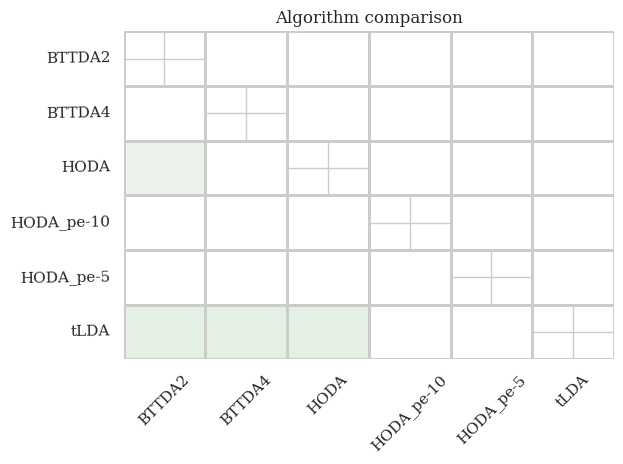

In [6]:
from moabb.analysis.meta_analysis import compute_dataset_statistics, find_significant_differences
from moabb.analysis.plotting import summary_plot
import matplotlib.pyplot as plt

stats = compute_dataset_statistics(results)
P, T = find_significant_differences(stats)
_ = summary_plot(P, T)

/usr/local/lib/python3.10/dist-packages/moabb/analysis/meta_analysis.py:26: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  return df.groupby(["pipeline", "dataset", "subject"]).mean().reset_index()


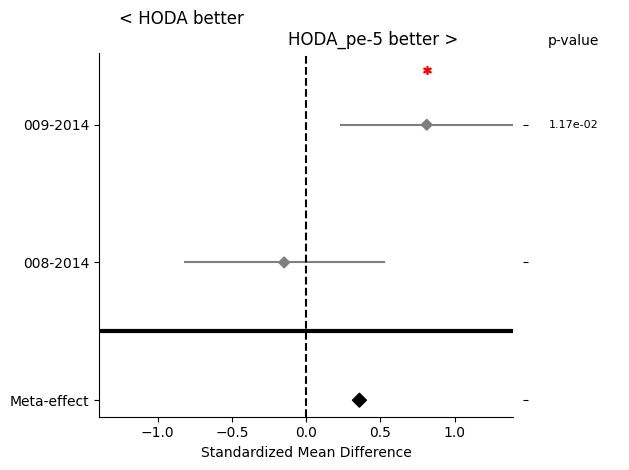

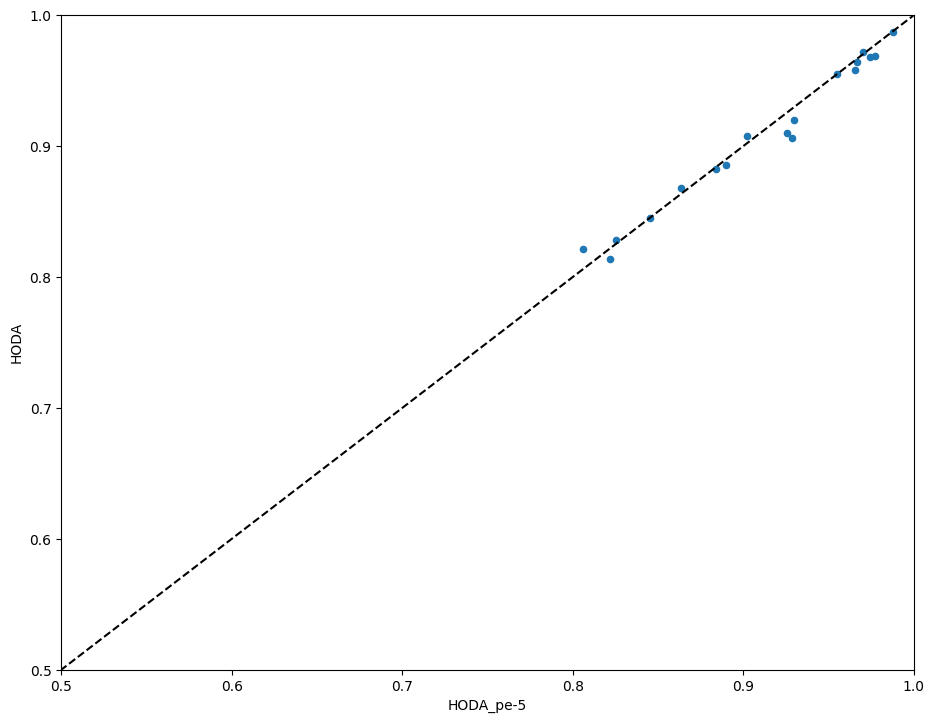

In [12]:
from moabb.analysis.plotting import meta_analysis_plot, paired_plot
_ = meta_analysis_plot(stats, 'HODA_pe-5', 'HODA')
_  = paired_plot(results, 'HODA_pe-5', 'HODA')

/usr/local/lib/python3.10/dist-packages/moabb/analysis/meta_analysis.py:26: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  return df.groupby(["pipeline", "dataset", "subject"]).mean().reset_index()


ValueError: Could not interpret value `HODA_rt` for parameter `x`

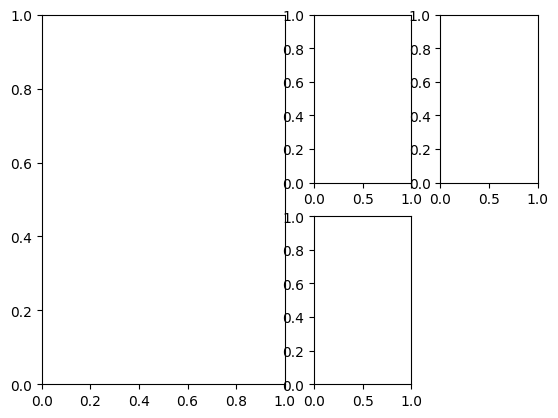

In [8]:
import seaborn as sns
from moabb.analysis.meta_analysis import (
    collapse_session_scores,
    combine_effects,
    combine_pvalues,
)
import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec



plt.style.use('default')
def paired_plot(data, alg1, alg2, ax, **kwargs):
    """Generate a figure with a paired plot.

    Parameters
    ----------
    data: DataFrame
        dataframe obtained from evaluation
    alg1: str
        Name of a member of column data.pipeline
    alg2: str
        Name of a member of column data.pipeline

    Returns
    -------
    fig: Figure
        Pyplot handle
    """
    cmap = ['#ef5513', '#f9c134']
    data = collapse_session_scores(data)
    data = data[data.pipeline.isin([alg1, alg2])]
    data = data.pivot_table(
        values="score", columns="pipeline", index=["subject", "dataset"]
    )
    data = data.reset_index()
    sns.scatterplot(data=data, x=alg1, y=alg2, ax=ax, hue='dataset', palette=cmap, **kwargs)
    ax.plot([0, 1], [0, 1], ls="--", c="grey")
    ax.set_xlim([0.75, 1])
    ax.set_ylim([0.75, 1])
    return fig

fig = plt.figure()

gs = GridSpec(2,3, figure=fig, width_ratios=[2.5,1,1],)
ax1 = fig.add_subplot(gs[:,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[0,2])
ax4 = fig.add_subplot(gs[1,1])

_=paired_plot(results, "HODA_rt", "BTTDA_rt_8", ax1, legend=True)
ax1.set_ylabel('BTTDA')
_=paired_plot(results, "XDAWN+RG", "BTTDA_rt_8", ax2, legend=False)
ax2.set_ylabel('')
ax2.set_xticks([])
ax2.set_yticks([])


_=paired_plot(results, "sLDA", "BTTDA_rt_8", ax3, legend=False)
ax3.set_ylabel('')
ax3.set_xticks([])
ax3.set_yticks([])

_=paired_plot(results, "tLDA", "BTTDA_rt_8", ax4, legend=False)
ax4.set_ylabel('')
ax4.set_xticks([])
ax4.set_yticks([])


fig.set_size_inches(7*0.7,4*0.7)
fig.tight_layout()
plt.savefig('roc_auc_results.pgf', bbox_inches='tight', pad_inches=0)